In [1]:
# Import all required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set chart style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\E_project\OLA_DataAnalyst_Project-main\OLA_DataAnalyst_Project-main\Bengaluru_Ola_Booking_Data.csv")
print("Data loaded successfully!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"\nColumn Names:\n{df.columns.tolist()}")

Data loaded successfully!
Total Rows: 50000
Total Columns: 21

Column Names:
['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for Cancelling by Customer', 'Cancelled Rides by Driver', 'Reason for Cancelling by Driver', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Payment Method', 'Ride Distance', 'Driver Ratings', 'Customer Rating']


In [3]:
print("=== DATASET OVERVIEW ===\n")
print(f"Total Rides: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"\n=== COLUMN DATA TYPES ===")
print(df.dtypes)
print(f"\n=== MISSING VALUES ===")
print(df.isnull().sum())
print(f"\n=== BASIC STATISTICS ===")
print(df[['Booking Value', 'Ride Distance', 
          'Driver Ratings', 'Customer Rating']].describe())

=== DATASET OVERVIEW ===

Total Rides: 50000
Total Columns: 21

=== COLUMN DATA TYPES ===
Date                                  object
Time                                  object
Booking ID                            object
Booking Status                        object
Customer ID                            int64
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer            int64
Reason for Cancelling by Customer     object
Cancelled Rides by Driver              int64
Reason for Cancelling by Driver       object
Incomplete Rides                       int64
Incomplete Rides Reason               object
Booking Value                        float64
Payment Method                        object
Ride Distance                        float64
Driver Ratings                       float64
Customer R

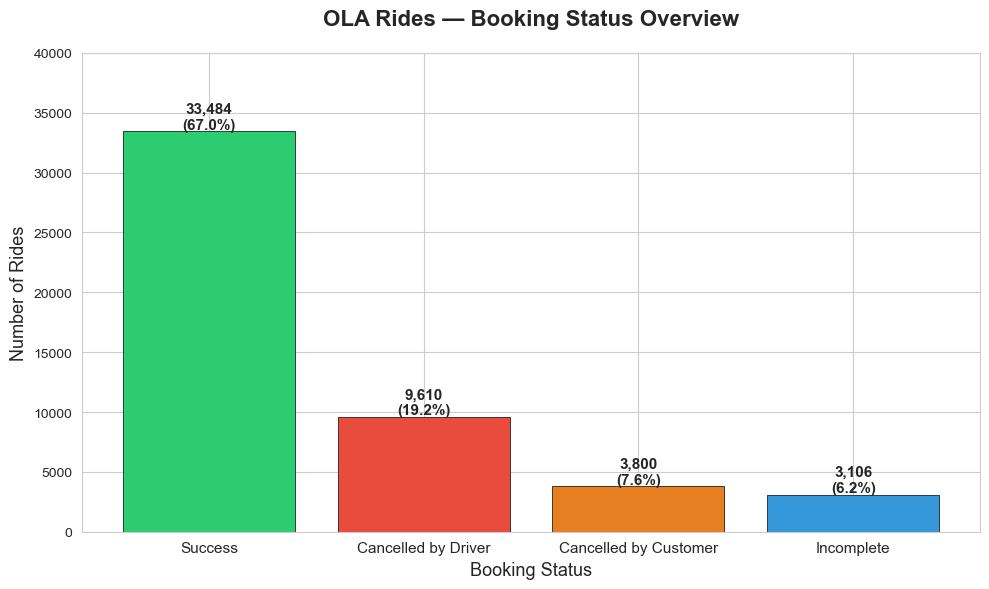

Chart 1 saved successfully!


In [4]:
# Chart 1 - Booking Status Overview
booking_status = df['Booking Status'].value_counts()

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db']

bars = plt.bar(booking_status.index, 
               booking_status.values, 
               color=colors,
               edgecolor='black',
               linewidth=0.5)

# Add value labels on top of bars
for bar, value in zip(bars, booking_status.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 200,
             f'{value:,}\n({value/50000*100:.1f}%)',
             ha='center', fontsize=11, fontweight='bold')

plt.title('OLA Rides — Booking Status Overview', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Booking Status', fontsize=13)
plt.ylabel('Number of Rides', fontsize=13)
plt.xticks(fontsize=11)
plt.ylim(0, 40000)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\OneDrive\Desktop\E_project\chart1_booking_status.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved successfully!")

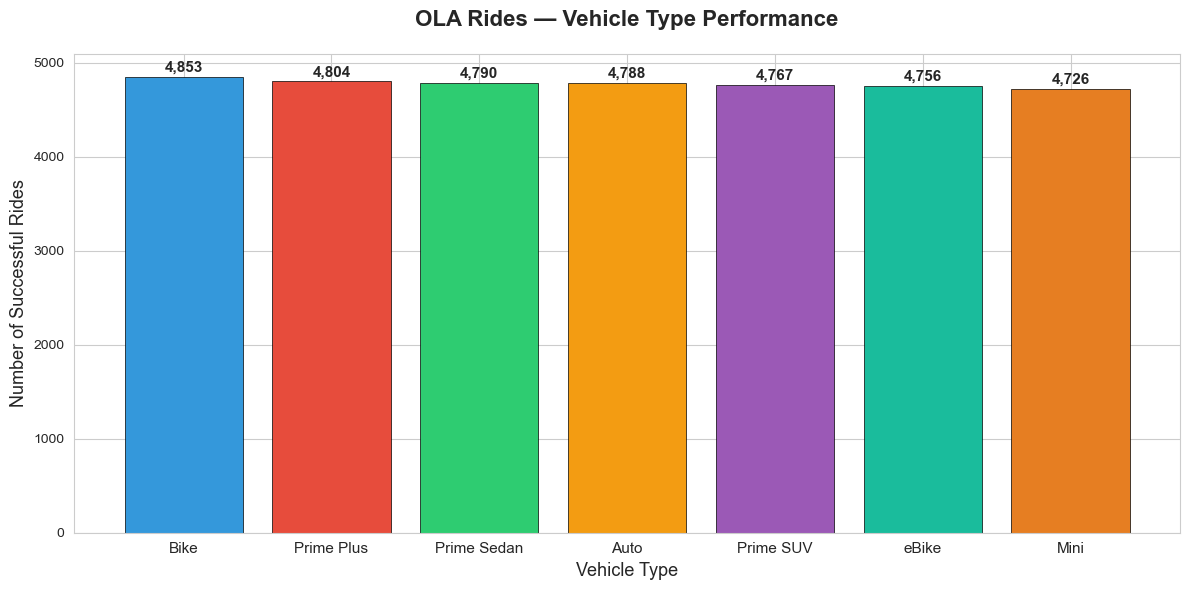

Chart 2 saved successfully!


In [5]:
# Chart 2 - Vehicle Type Performance
vehicle_data = df[df['Booking Status'] == 'Success']['Vehicle Type'].value_counts()

plt.figure(figsize=(12, 6))
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']

bars = plt.bar(vehicle_data.index,
               vehicle_data.values,
               color=colors,
               edgecolor='black',
               linewidth=0.5)

# Add value labels
for bar, value in zip(bars, vehicle_data.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{value:,}',
             ha='center', fontsize=11, fontweight='bold')

plt.title('OLA Rides — Vehicle Type Performance', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vehicle Type', fontsize=13)
plt.ylabel('Number of Successful Rides', fontsize=13)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\OneDrive\Desktop\E_project\chart2_vehicle_type.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved successfully!")

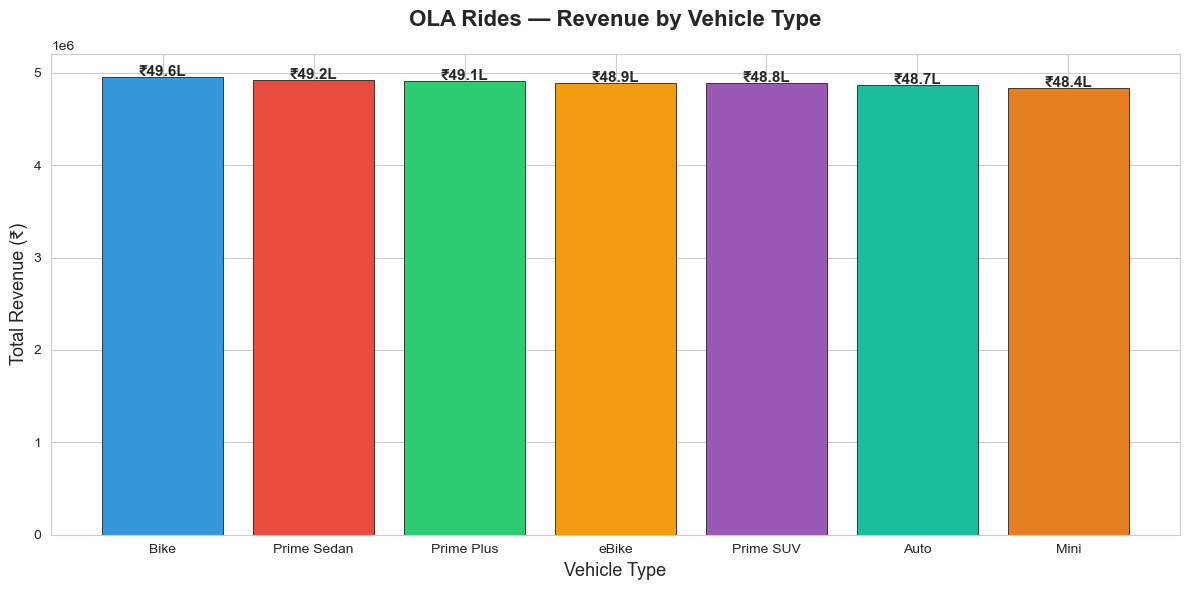

✅ Chart 3 saved!


In [6]:
# Chart 3 - Revenue by Vehicle Type
revenue_data = df[df['Booking Status']=='Success'].groupby('Vehicle Type')['Booking Value'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
bars = plt.bar(revenue_data.index, revenue_data.values,
               color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22'],
               edgecolor='black', linewidth=0.5)
for bar, value in zip(bars, revenue_data.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10000,
             f'₹{value/100000:.1f}L',
             ha='center', fontsize=11, fontweight='bold')
plt.title('OLA Rides — Revenue by Vehicle Type', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vehicle Type', fontsize=13)
plt.ylabel('Total Revenue (₹)', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\OneDrive\Desktop\E_project\chart3_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

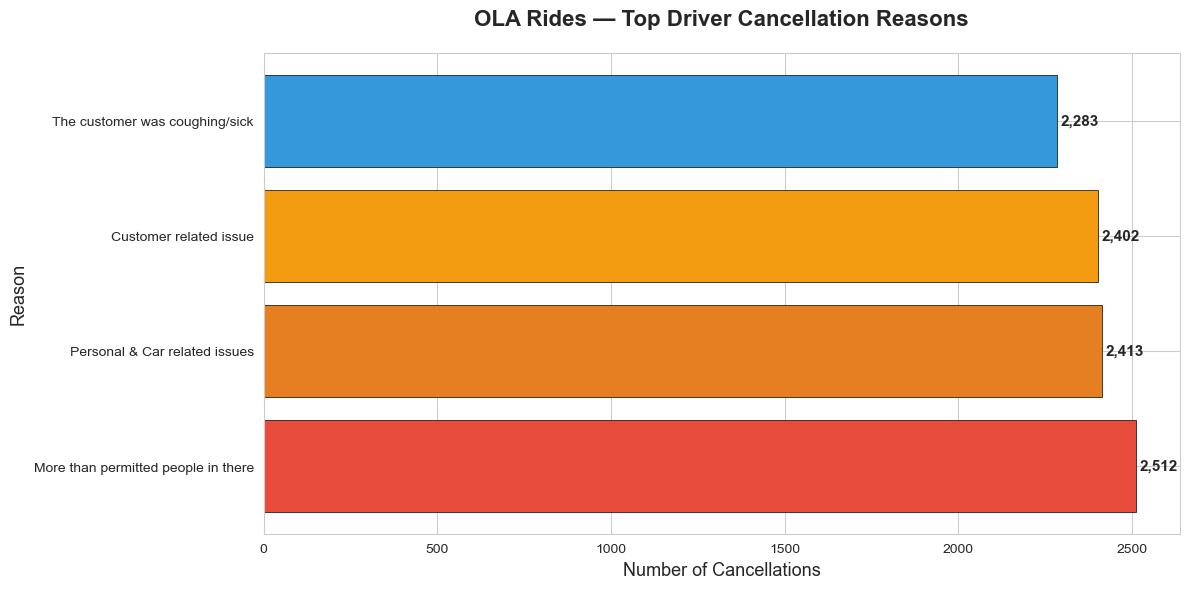

Chart 4 saved!


In [7]:
# Chart 4 - Top Cancellation Reasons by Driverprint("\n🎉 ALL CHARTS COMPLETED SUCCESSFULLY!")
driver_cancel = df[df['Booking Status']=='Cancelled by Driver']['Reason for Cancelling by Driver'].value_counts().head(5)

plt.figure(figsize=(12,6))
bars = plt.barh(driver_cancel.index, driver_cancel.values,
                color=['#e74c3c','#e67e22','#f39c12','#3498db','#9b59b6'],
                edgecolor='black', linewidth=0.5)
for bar, value in zip(bars, driver_cancel.values):
    plt.text(value + 10, bar.get_y() + bar.get_height()/2,
             f'{value:,}', va='center', fontsize=11, fontweight='bold')
plt.title('OLA Rides — Top Driver Cancellation Reasons', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Cancellations', fontsize=13)
plt.ylabel('Reason', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\OneDrive\Desktop\E_project\chart4_driver_cancellation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

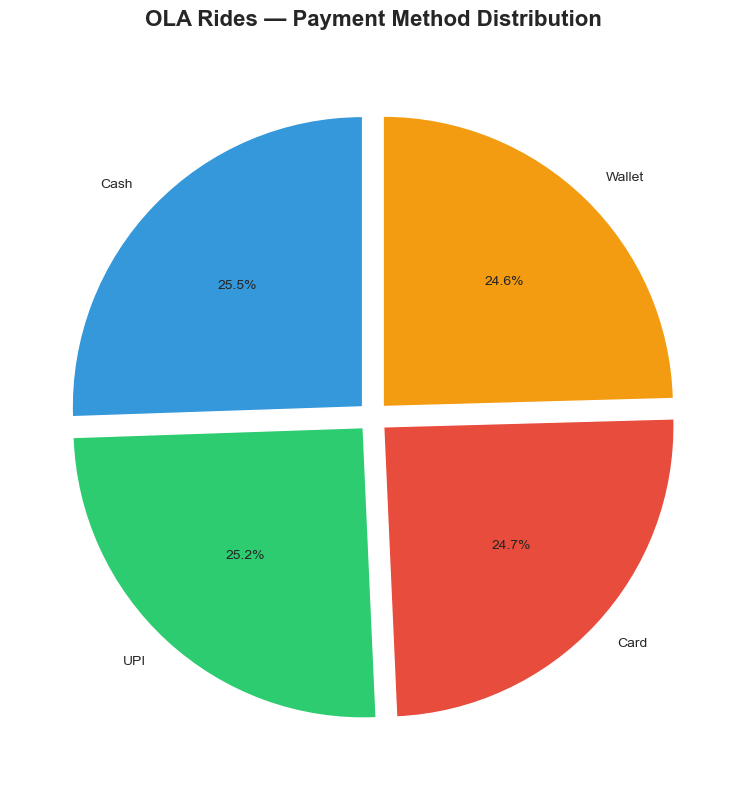

✅ Chart 5 saved!


In [8]:
# Chart 5 - Payment Method Analysis
payment_data = df[df['Booking Status']=='Success']['Payment Method'].value_counts()

plt.figure(figsize=(8,8))
colors = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']
plt.pie(payment_data.values,
        labels=payment_data.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        explode=[0.05]*len(payment_data))
plt.title('OLA Rides — Payment Method Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\OneDrive\Desktop\E_project\chart5_payment_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

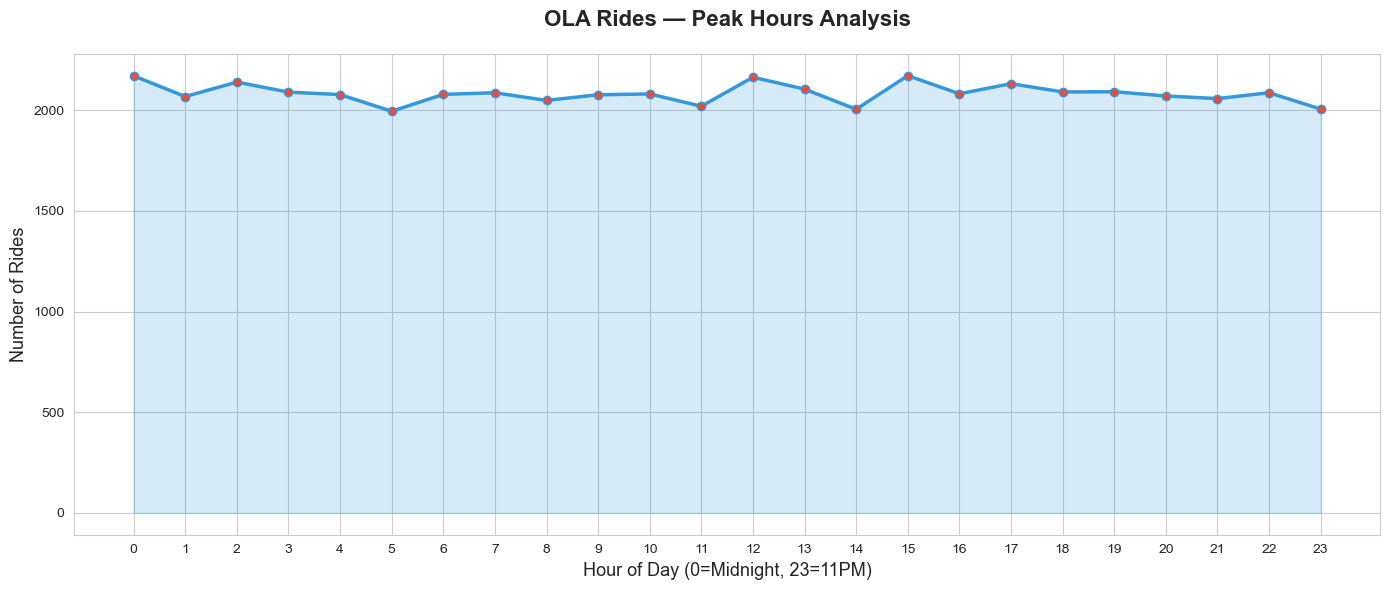

Chart 6 saved!


In [9]:
# Chart 6 - Peak Hours Analysis
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour
hourly_data = df.groupby('Hour').size()

plt.figure(figsize=(14,6))
plt.plot(hourly_data.index, hourly_data.values,
         color='#3498db', linewidth=2.5,
         marker='o', markersize=6, markerfacecolor='#e74c3c')
plt.fill_between(hourly_data.index, hourly_data.values,
                 alpha=0.2, color='#3498db')
plt.title('OLA Rides — Peak Hours Analysis', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hour of Day (0=Midnight, 23=11PM)', fontsize=13)
plt.ylabel('Number of Rides', fontsize=13)
plt.xticks(range(0,24), fontsize=10)
plt.tight_layout()
plt.savefig(r'C:\Users\HP\OneDrive\Desktop\E_project\chart6_peak_hours.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")